In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("ASSIT.csv")
print(df.head())

   problem_log_id                                 skill  problem_id  user_id  \
0       137792159                                   NaN      557460    61394   
1       138083797                              Rounding      365981    61394   
2       142332619  Multiplication and Division Integers      426415    61394   
3       145939397                            Proportion       86686    61394   
4       137111284                                   NaN      399669    76592   

   assignment_id  assistment_id           start_time                 end_time  \
0         565736         341511  2012-09-28 15:11:27  2012-09-28 15:11:36.856   
1         573819         204043  2012-10-09 11:01:52  2012-10-09 11:02:13.182   
2         734130         247525  2013-03-07 10:53:20  2013-03-07 10:53:28.661   
3         821352          48081  2013-08-20 19:54:56  2013-08-20 19:55:21.753   
4         557216         227869  2012-09-10 17:20:10  2012-09-10 17:24:56.579   

  problem_type  original  ...  o

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6123270 entries, 0 to 6123269
Data columns (total 35 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   problem_log_id                     int64  
 1   skill                              str    
 2   problem_id                         int64  
 3   user_id                            int64  
 4   assignment_id                      int64  
 5   assistment_id                      int64  
 6   start_time                         str    
 7   end_time                           str    
 8   problem_type                       str    
 9   original                           int64  
 10  correct                            float64
 11  bottom_hint                        float64
 12  hint_count                         int64  
 13  actions                            str    
 14  attempt_count                      int64  
 15  ms_first_response                  int64  
 16  tutor_mode                   

In [4]:
print(df.columns.tolist())

['problem_log_id', 'skill', 'problem_id', 'user_id', 'assignment_id', 'assistment_id', 'start_time', 'end_time', 'problem_type', 'original', 'correct', 'bottom_hint', 'hint_count', 'actions', 'attempt_count', 'ms_first_response', 'tutor_mode', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'teacher_id', 'school_id', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'problemlogid', 'Average_confidence(FRUSTRATED)', 'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)', 'Average_confidence(BORED)']


In [5]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

SEED = 20260305
RNG = np.random.default_rng(SEED)


raw_count = len(df)
mask_valid = (df['ms_first_response'] >= 1000) & (df['ms_first_response'] <= 600000)
df = df[mask_valid].copy()
print(f"Rows before filtering: {raw_count:,}")
print(f"Rows after filtering:  {len(df):,}  ({len(df)/raw_count*100:.1f}%)")

# Compute response time
df['response_time_sec'] = df['ms_first_response'] / 1000.0
df['log_response_time'] = np.log10(df['response_time_sec'])

# Sort data by time
df['start_time'] = pd.to_datetime(df['start_time'], format="ISO8601")
df = df.sort_values(by=['user_id', 'start_time']).reset_index(drop=True)

# Past correct rate (default 0.5 for first problem)
df['past_correct_rate'] = (
    df.groupby('user_id')['correct']
    .transform(lambda x: x.shift().expanding().mean().fillna(0.5))
)

# Past average hint count per problem
df['past_hint_rate'] = (
    df.groupby('user_id')['hint_count']
    .transform(lambda x: x.shift().expanding().mean().fillna(0.0))
)

# Fill affect columns with 0 (missing = no detected affect)
affect_cols = [
    'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]
df[affect_cols] = df[affect_cols].fillna(0)

# Summary statistics
print(f"\nResponse time (seconds):")
print(f"  Median: {df['response_time_sec'].median():.1f}s")
print(f"  IQR:    [{df['response_time_sec'].quantile(0.25):.1f}s, {df['response_time_sec'].quantile(0.75):.1f}s]")
print(f"  Mean:   {df['response_time_sec'].mean():.1f}s")
print(f"\nLog10(response_time):")
print(f"  Median: {df['log_response_time'].median():.3f}")
print(f"  IQR:    [{df['log_response_time'].quantile(0.25):.3f}, {df['log_response_time'].quantile(0.75):.3f}]")

Rows before filtering: 6,123,270
Rows after filtering:  6,117,279  (99.9%)

Response time (seconds):
  Median: 22.4s
  IQR:    [9.5s, 54.9s]
  Mean:   48.1s

Log10(response_time):
  Median: 1.350
  IQR:    [0.976, 1.740]


# Action

In [6]:
import itertools

# Action Space: problem_type × original
action_cols = ['problem_type', 'original']
problem_types = sorted(df['problem_type'].dropna().unique())
originals = sorted(df['original'].unique())

all_action_combinations = list(itertools.product(problem_types, originals))
action_df = pd.DataFrame(all_action_combinations, columns=action_cols)
action_df['action_id'] = action_df.index

# Map rows to action_id
action_mapping = action_df.set_index(action_cols)['action_id'].to_dict()
df['action_id'] = df.set_index(action_cols).index.map(action_mapping)
df = df.dropna(subset=['action_id'])
df['action_id'] = df['action_id'].astype(int)

# Compute per-action statistics
action_stats = df.groupby('action_id').agg(
    median_rt=('response_time_sec', 'median'),
    q25_rt=('response_time_sec', lambda x: x.quantile(0.25)),
    q75_rt=('response_time_sec', lambda x: x.quantile(0.75)),
    mean_rt=('response_time_sec', 'mean'),
    correct_rate=('correct', 'mean'),
    count=('correct', 'count')
).reset_index()
action_df = action_df.merge(action_stats, on='action_id', how='left')

# Filter: keep actions with >= 100 observations
MIN_ACTION_COUNT = 100
valid_actions = action_df[action_df['count'] >= MIN_ACTION_COUNT]['action_id'].values
print(f"Actions before filtering: {len(action_df)}")
print(f"Actions after filtering (count >= {MIN_ACTION_COUNT}): {len(valid_actions)}")

# Filter df and action_df
df = df[df['action_id'].isin(valid_actions)].copy()
action_df = action_df[action_df['action_id'].isin(valid_actions)].copy()

# Re-index actions to 0..N-1
old_to_new = {old: new for new, old in enumerate(sorted(valid_actions))}
df['action_id'] = df['action_id'].map(old_to_new)
action_df['action_id'] = action_df['action_id'].map(old_to_new)
NUM_ACTIONS = len(action_df)

# Per-action log-median
action_df['log_median_rt'] = np.log10(action_df['median_rt'])

print(f"\nNUM_ACTIONS = {NUM_ACTIONS}")
print(action_df[['action_id', 'problem_type', 'original',
                  'median_rt', 'log_median_rt', 'q25_rt', 'q75_rt',
                  'correct_rate', 'count']].to_string(index=False))

Actions before filtering: 12
Actions after filtering (count >= 100): 10

NUM_ACTIONS = 10
 action_id  problem_type  original  median_rt  log_median_rt  q25_rt    q75_rt  correct_rate     count
         0       algebra         0    11.7160       1.068779  5.0550  30.05100      0.380741  128221.0
         1       algebra         1    26.9840       1.431106 11.2570  63.29100      0.677543 3367980.0
         2      choose_1         0     8.1220       0.909663  4.3170  17.68600      0.811904  127222.0
         3      choose_1         1    16.0770       1.206205  7.5160  39.03600      0.704962 1719882.0
         4      choose_n         0    11.2360       1.050612  5.0590  19.42700      0.600000     295.0
         5      choose_n         1    13.2940       1.123656  7.6455  27.90225      0.787611   11300.0
         6     fill_in_1         0    11.1615       1.047723  4.8910  25.81425      0.334879   46590.0
         7     fill_in_1         1    28.5840       1.456123 12.2630  66.09800      0.

# State

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

NUM_STATES = 100

state_features = [
    'past_correct_rate',
    'past_hint_rate',
    'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]

# Standardize features for K-Means
scaler = StandardScaler()
X_state = scaler.fit_transform(df[state_features].values)

# K-Means clustering
kmeans = KMeans(n_clusters=NUM_STATES, random_state=SEED, n_init=10, max_iter=300)
df['state_id'] = kmeans.fit_predict(X_state)

# Save centroids in ORIGINAL scale (not standardized) for interpretability
centroids_raw = scaler.inverse_transform(kmeans.cluster_centers_)
centroids = pd.DataFrame(centroids_raw, columns=state_features)
centroids.index.name = 'state_id'

print(f"Number of states: {NUM_STATES}")
print(f"\nState distribution (top 10):")
print(df['state_id'].value_counts().head(10))
print(f"\nCentroid summary (first 5 states):")
print(centroids.head().round(3).to_string())

Number of states: 100

State distribution (top 10):
state_id
93    306617
8     279945
64    225111
14    209342
85    184940
49    169574
54    163720
73    158675
0     145098
59    139077
Name: count, dtype: int64

Centroid summary (first 5 states):
          past_correct_rate  past_hint_rate  Average_confidence(FRUSTRATED)  Average_confidence(CONFUSED)  Average_confidence(CONCENTRATING)  Average_confidence(BORED)
state_id                                                                                                                                                               
0                     0.675           0.131                           0.362                         0.001                              0.767                      0.234
1                     0.595           0.684                           0.362                         0.004                              0.338                      0.064
2                     0.865           0.057                           0.361

# Reward

RF predicting median_log_rt (response time, not reward):
  RMSE: 0.1078 ± 0.0084
  R²:   0.8910 ± 0.0160

Final mu_r matrix: (100, 10)
  Range:  [0.43, 28.70]
  Mean:   18.95
  Std:    6.57
  Median: 20.43


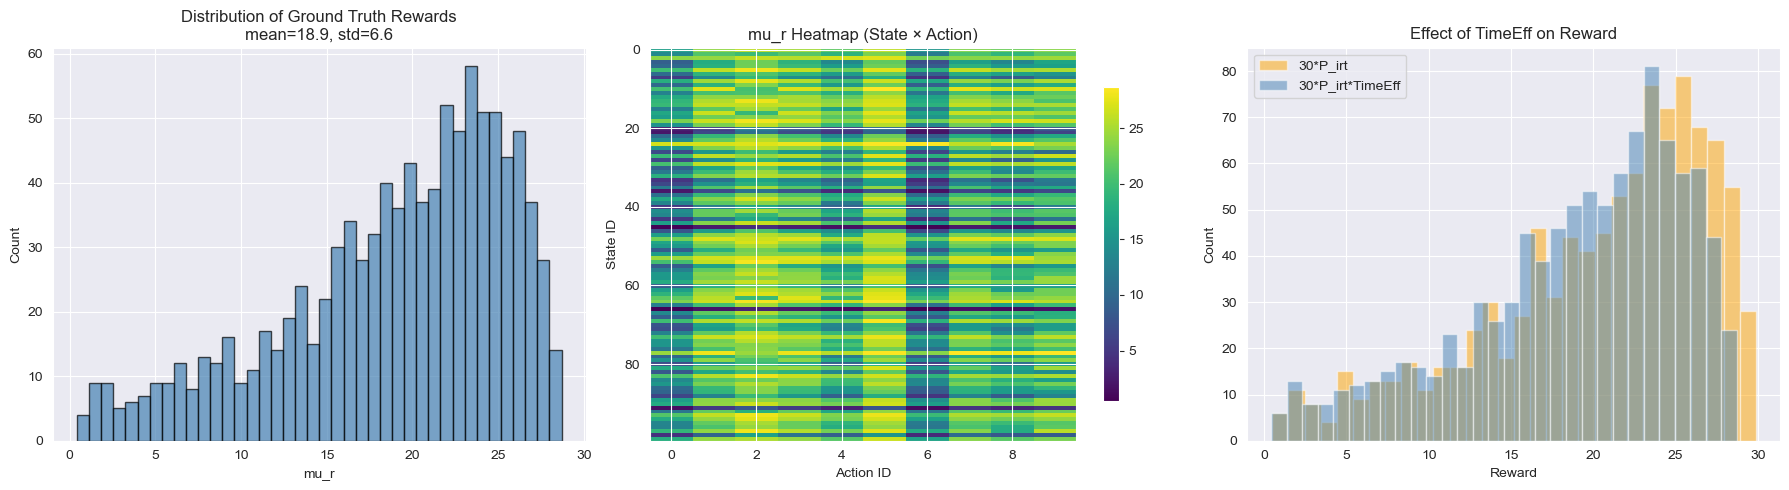

In [14]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

ALPHA = 0.4          # sensitivity of TimeEff to response time deviation
MIN_EFF = 0.3
MAX_REWARD = 30.0

def compute_time_efficiency(log_rt, action_log_median, alpha=ALPHA, min_eff=MIN_EFF):
    """
    The deviation of student response time from the median response time in this question.
    If it is too large, student struggled and can't understand.
    If it it too small, student didn't pay attention.
    """
    deviation = np.abs(np.asarray(log_rt) - np.asarray(action_log_median))
    return np.maximum(min_eff, 1.0 - alpha * deviation)

def compute_reward(P_irt, log_rt, action_log_median,
                   alpha=ALPHA, min_eff=MIN_EFF, max_r=MAX_REWARD):
    """R = max_r * P_irt * TimeEff(log_rt, target)."""
    te = compute_time_efficiency(log_rt, action_log_median, alpha, min_eff)
    return max_r * np.asarray(P_irt) * te



# IRT Component (fully data-driven)
# theta_s = logit(past_correct_rate) per state
state_theta = np.log(
    centroids['past_correct_rate'].clip(0.02, 0.98) /
    (1 - centroids['past_correct_rate'].clip(0.02, 0.98))
)
# b_a = logit(error_rate) per action
action_cr = action_df['correct_rate'].fillna(0.5).clip(0.02, 0.98)
action_b = np.log((1 - action_cr.values) / action_cr.values)
action_df['b'] = action_b
action_df['log_median_rt'] = np.log10(action_df['median_rt'])

# P_irt
all_sa = pd.MultiIndex.from_product(
    [range(NUM_STATES), range(NUM_ACTIONS)], names=['state_id', 'action_id']
).to_frame(index=False)

all_sa['theta'] = all_sa['state_id'].map(state_theta)
all_sa['b'] = all_sa['action_id'].map(dict(enumerate(action_b)))
all_sa['P_irt'] = 1.0 / (1.0 + np.exp(-(all_sa['theta'] - all_sa['b'])))



# (s,a) median response time
sa_observed = df.groupby(['state_id', 'action_id']).agg(
    sa_median_log_rt=('log_response_time', 'median'),
    sa_count=('log_response_time', 'count')
).reset_index()

all_sa = all_sa.merge(sa_observed, on=['state_id', 'action_id'], how='left')
all_sa['action_log_median'] = all_sa['action_id'].map(
    action_df.set_index('action_id')['log_median_rt']
)

# RF to predict missing pairs
MIN_OBS = 20
observed_mask = all_sa['sa_count'].fillna(0) >= MIN_OBS
observed = all_sa[observed_mask].copy()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
action_cats = all_sa[['action_id']].astype(str)
action_encoded_all = encoder.fit_transform(action_cats)

X_all = np.hstack([
    centroids.loc[all_sa['state_id'].values, state_features].values,
    action_encoded_all
])
X_obs = X_all[observed_mask.values]
y_obs = observed['sa_median_log_rt'].values

rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_obs, y_obs)

# Cross-validate
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
rmse_scores = np.sqrt(-cross_val_score(rf, X_obs, y_obs, cv=kf, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(rf, X_obs, y_obs, cv=kf, scoring='r2')
print(f"RF predicting median_log_rt (response time, not reward):")
print(f"  RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"  R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Fill missing pairs
all_sa['predicted_log_rt'] = rf.predict(X_all)
all_sa['final_log_rt'] = all_sa['sa_median_log_rt'].fillna(all_sa['predicted_log_rt'])

# Compute final mu_r
all_sa['time_eff'] = compute_time_efficiency(
    all_sa['final_log_rt'].values, all_sa['action_log_median'].values
)
all_sa['mu_r'] = MAX_REWARD * all_sa['P_irt'] * all_sa['time_eff']

# Pivot to matrix
mu_r = all_sa.pivot(index='state_id', columns='action_id', values='mu_r').values

# Compute sigma_r_sq from data (reward variance within each (s,a))
def _reward_var(group, action_log_med_map, theta_map, b_map, alpha=ALPHA):
    s, a = group.name
    theta = theta_map[s]; b = b_map[a]
    p = 1.0 / (1.0 + np.exp(-(theta - b)))
    te = compute_time_efficiency(group['log_response_time'].values,
                                  action_log_med_map[a], alpha)
    rewards = MAX_REWARD * p * te
    return rewards.var()

_theta_map = state_theta.to_dict()
_b_map = dict(enumerate(action_b))
_alm_map = action_df.set_index('action_id')['log_median_rt'].to_dict()

sa_var = df.groupby(['state_id', 'action_id']).apply(
    _reward_var, _alm_map, _theta_map, _b_map
).reset_index()
sa_var.columns = ['state_id', 'action_id', 'data_sigma_sq']

all_sa = all_sa.merge(sa_var, on=['state_id', 'action_id'], how='left')
sigma_r_sq_data = all_sa.pivot(
    index='state_id', columns='action_id', values='data_sigma_sq'
).values
sigma_r_sq_data = np.nan_to_num(sigma_r_sq_data, nan=np.nanmean(sigma_r_sq_data[~np.isnan(sigma_r_sq_data)]))

# Summary & Visualization
print(f"\n{'='*50}")
print(f"Final mu_r matrix: {mu_r.shape}")
print(f"  Range:  [{mu_r.min():.2f}, {mu_r.max():.2f}]")
print(f"  Mean:   {mu_r.mean():.2f}")
print(f"  Std:    {mu_r.std():.2f}")
print(f"  Median: {np.median(mu_r):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(mu_r.flatten(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('mu_r'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Distribution of Ground Truth Rewards\nmean={mu_r.mean():.1f}, std={mu_r.std():.1f}')

im = axes[1].imshow(mu_r, aspect='auto', cmap='viridis')
axes[1].set_xlabel('Action ID'); axes[1].set_ylabel('State ID')
axes[1].set_title('mu_r Heatmap (State × Action)')
plt.colorbar(im, ax=axes[1], shrink=0.8)

axes[2].hist(all_sa['P_irt'].values * 30, bins=30, alpha=0.5, label='30*P_irt', color='orange')
axes[2].hist(mu_r.flatten(), bins=30, alpha=0.5, label='30*P_irt*TimeEff', color='steelblue')
axes[2].set_xlabel('Reward'); axes[2].set_ylabel('Count')
axes[2].set_title('Effect of TimeEff on Reward')
axes[2].legend()

plt.tight_layout()
plt.savefig('assist_reward.png', dpi=300)
plt.show()

# Simulator

In [9]:
# d0: initial state distribution from data
state_counts = df['state_id'].value_counts().reindex(range(NUM_STATES)).fillna(0).values
d0 = state_counts / state_counts.sum()
d0 = np.clip(d0, 1e-5, 1.0)
d0 = d0 / d0.sum()

# Custom parameters
NUM_PATIENTS = 6000
sigma_r_sq = RNG.uniform(low=30, high=60, size=(NUM_STATES, NUM_ACTIONS))
pi_b = RNG.dirichlet(np.ones(NUM_ACTIONS) * 0.5, size=NUM_STATES)
pi_b = np.clip(pi_b, 0.05, 1.0)
pi_b = pi_b / pi_b.sum(axis=1, keepdims=True)

FLIP_PROB = 0.1
pi_e = pi_b.copy()
for s in range(NUM_STATES):
    if RNG.random() < FLIP_PROB:
        perm = RNG.permutation(NUM_ACTIONS)
        pi_e[s] = pi_e[s][perm]

patient_states = RNG.multinomial(NUM_PATIENTS, d0)
n_f = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=int)
for s in range(NUM_STATES):
    if patient_states[s] > 0:
        n_f[s] = RNG.multinomial(patient_states[s], pi_b[s])

save_path = "ASSIST_params_irt_time.npz"
np.savez(save_path,
         mu_r=mu_r,
         sigma_r_sq=sigma_r_sq,
         pi_b=pi_b,
         pi_e=pi_e,
         d0=d0,
         num_states=NUM_STATES,
         num_actions=NUM_ACTIONS)

print(f"Parameters saved to: {save_path}")
print(f"  mu_r:      {mu_r.shape},  range [{mu_r.min():.2f}, {mu_r.max():.2f}], mean={mu_r.mean():.2f}")
print(f"  sigma_r_sq:{sigma_r_sq.shape}, range [{sigma_r_sq.min():.1f}, {sigma_r_sq.max():.1f}]")
print(f"  pi_b:      {pi_b.shape}")
print(f"  pi_e:      {pi_e.shape}")
print(f"  d0:        {d0.shape}")

Parameters saved to: ASSIST_params_irt_time.npz
  mu_r:      (100, 10),  range [0.43, 28.70], mean=18.95
  sigma_r_sq:(100, 10), range [30.0, 60.0]
  pi_b:      (100, 10)
  pi_e:      (100, 10)
  d0:        (100,)


# LLM

## Prompt

In [10]:
import json
from pydantic import BaseModel, Field

# State descriptions (one per state)
state_info = {}
for s in range(NUM_STATES):
    cr = centroids.loc[s, 'past_correct_rate']
    if cr >= 0.8:   level = "high-performing"
    elif cr >= 0.6: level = "average"
    elif cr >= 0.4: level = "below-average"
    else:           level = "struggling"
    state_info[s] = {
        'level': level,
        'correct_rate': cr,
        'hint_rate': centroids.loc[s, 'past_hint_rate'],
        'frustration': centroids.loc[s, 'Average_confidence(FRUSTRATED)'],
        'confusion': centroids.loc[s, 'Average_confidence(CONFUSED)'],
        'concentration': centroids.loc[s, 'Average_confidence(CONCENTRATING)'],
        'boredom': centroids.loc[s, 'Average_confidence(BORED)'],
    }

# Action descriptions (one per action)
action_info = {}
for _, row in action_df.iterrows():
    a = int(row['action_id'])
    action_info[a] = {
        'problem_type': row['problem_type'],
        'original': int(row['original']),
        'median_rt': row['median_rt'],
        'q25_rt': row['q25_rt'],
        'q75_rt': row['q75_rt'],
        'correct_rate': row['correct_rate'],
        'log_median_rt': row['log_median_rt'],
    }

# Historical RT samples: precompute for every (s,a) pair
# Sample 8 sorted response times from data for each (s,a)
N_HIST_SAMPLES = 8
rt_samples_cache = {}

# Group once, sample once
for (s, a), group in df.groupby(['state_id', 'action_id']):
    vals = group['response_time_sec'].values
    if len(vals) >= N_HIST_SAMPLES:
        idx = RNG.choice(len(vals), size=N_HIST_SAMPLES, replace=False)
        rt_samples_cache[(s, a)] = sorted(vals[idx])
    else:
        rt_samples_cache[(s, a)] = sorted(vals)

# Fallback samples per action (for missing (s,a) pairs)
action_fallback_samples = {}
for a in range(NUM_ACTIONS):
    vals = df[df['action_id'] == a]['response_time_sec'].values
    if len(vals) >= N_HIST_SAMPLES:
        idx = RNG.choice(len(vals), size=N_HIST_SAMPLES * 3, replace=False)
        action_fallback_samples[a] = sorted(vals[idx][:N_HIST_SAMPLES])
    else:
        action_fallback_samples[a] = sorted(vals)

def get_rt_samples(s, a):
    """Get historical RT samples for a (state, action) pair."""
    if (s, a) in rt_samples_cache:
        return rt_samples_cache[(s, a)]
    return action_fallback_samples.get(a, [10.0, 20.0, 30.0])

# P_irt lookup (precomputed, not from LLM)
pirt_lookup = all_sa.set_index(['state_id', 'action_id'])['P_irt'].to_dict()

print(f"Precomputed: {len(state_info)} states, {len(action_info)} actions, "
      f"{len(rt_samples_cache)} (s,a) RT sample sets")

# Schema for structured output

class PairPrediction(BaseModel):
    state_id: int = Field(description="The state_id from the prompt.")
    action_id: int = Field(description="The action_id from the prompt.")
    predicted_response_time_seconds: float = Field(
        description="Predicted seconds from problem presentation to student's first response."
    )

class BatchPrediction(BaseModel):
    predictions: list[PairPrediction] = Field(
        description="One prediction per student-problem pair in the batch."
    )

# Prompt building
# Action reference table (static, included once per prompt)
ACTION_TABLE_STR = "| ID | Problem Type   | Original | Median RT | IQR (seconds)      | Correct Rate |\n"
ACTION_TABLE_STR += "|" + "-"*4 + "|" + "-"*16 + "|" + "-"*10 + "|" + "-"*11 + "|" + "-"*20 + "|" + "-"*14 + "|\n"
for _, row in action_df.iterrows():
    ACTION_TABLE_STR += (
        f"| {int(row['action_id']):2d} | {row['problem_type']:14s} | "
        f"{'Yes' if row['original']==1 else 'No':8s} | "
        f"{row['median_rt']:7.1f}s  | "
        f"[{row['q25_rt']:5.1f}s, {row['q75_rt']:6.1f}s] | "
        f"{row['correct_rate']:.3f}        |\n"
    )

SYSTEM_PROMPT = f"""You are an expert in educational data mining and intelligent tutoring systems.
Your task: predict the **response time in seconds** for students solving math problems on the ASSISTments platform.

"Response time" = seconds from when a problem appears on screen until the student's first action (submitting an answer OR requesting a hint).

## Action Reference (Problem Types)
{ACTION_TABLE_STR}
## Key Factors Affecting Response Time
1. **Student ability** (past correct rate): Higher-performing students tend to respond faster, especially on familiar problem types. Struggling students take longer or give up quickly.
2. **Hint-seeking habit** (avg hints/problem): Students who frequently use hints often pause longer before their first action, deciding whether to attempt or request help.
3. **Emotional state**: Frustrated/confused students → longer response times. Bored students → may rush (shorter) or disengage (much longer). Concentrated students → moderate, productive times.
4. **Problem type**: Multiple choice (choose_1) is fastest. Open response and rank problems are slowest. Algebra and fill-in fall in between.
5. **Original vs Scaffolding**: Scaffolding problems (original=No) are simpler sub-problems, typically answered 30-50% faster than original problems of the same type.
6. **Interaction effects**: A struggling student on a hard algebra problem will take much longer than a high-performing student on an easy multiple-choice problem.

## Historical Response Time Samples
For each pair below, we provide actual response times from similar students on similar problems. These samples reflect the REAL distribution — use them to calibrate your prediction.

## Your Task
For each student-problem pair, predict a single number: the response time in seconds. Consider all factors above and the historical samples carefully. Output must be valid JSON matching the schema."""


def build_batch_prompt(batch_pairs):
    pair_blocks = []
    for i, (s, a) in enumerate(batch_pairs, 1):
        si = state_info[s]
        ai = action_info[a]
        samples = get_rt_samples(s, a)
        samples_str = ", ".join(f"{v:.1f}s" for v in samples)

        pair_blocks.append(
            f"--- Pair {i} (state_id: {s}, action_id: {a}) ---\n"
            f"Student: {si['level']}, correct_rate={si['correct_rate']:.2f}, "
            f"avg_hints={si['hint_rate']:.2f}, "
            f"frustration={si['frustration']:.2f}, confusion={si['confusion']:.2f}, "
            f"concentration={si['concentration']:.2f}, boredom={si['boredom']:.2f}\n"
            f"Problem: {ai['problem_type']}, original={'Yes' if ai['original']==1 else 'No'}, "
            f"typical_median={ai['median_rt']:.1f}s\n"
            f"Historical response times from similar cases: [{samples_str}]"
        )

    return SYSTEM_PROMPT + "\n\n" + "\n\n".join(pair_blocks) + "\n"


# est prompt
test_prompt = build_batch_prompt([(0, 0), (1, 3)])
print(f"Sample batch prompt length: {len(test_prompt)} chars")
print(test_prompt)

Precomputed: 100 states, 10 actions, 946 (s,a) RT sample sets
Sample batch prompt length: 3499 chars
You are an expert in educational data mining and intelligent tutoring systems.
Your task: predict the **response time in seconds** for students solving math problems on the ASSISTments platform.

"Response time" = seconds from when a problem appears on screen until the student's first action (submitting an answer OR requesting a hint).

## Action Reference (Problem Types)
| ID | Problem Type   | Original | Median RT | IQR (seconds)      | Correct Rate |
|----|----------------|----------|-----------|--------------------|--------------|
|  0 | algebra        | No       |    11.7s  | [  5.1s,   30.1s] | 0.381        |
|  1 | algebra        | Yes      |    27.0s  | [ 11.3s,   63.3s] | 0.678        |
|  2 | choose_1       | No       |     8.1s  | [  4.3s,   17.7s] | 0.812        |
|  3 | choose_1       | Yes      |    16.1s  | [  7.5s,   39.0s] | 0.705        |
|  4 | choose_n       | No    

## Gemini

In [11]:
from google import genai
from google.genai import types
from tqdm.asyncio import tqdm as async_tqdm

API_KEY = "your_api_key"
client = genai.Client(api_key=API_KEY)


async def fetch_batch_prediction(batch_pairs, rep_id, model_name,
                                  semaphore, temperature=0.8, max_retries=3):

    prompt = build_batch_prompt(batch_pairs)

    async with semaphore:
        for attempt in range(max_retries):
            try:
                response = await client.aio.models.generate_content(
                    model=model_name,
                    contents=prompt,
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=BatchPrediction,
                        temperature=temperature,
                    ),
                )
                parsed = json.loads(response.text)
                preds = parsed.get("predictions", [])

                results = []
                # pair i → prediction i
                for i, (s, a) in enumerate(batch_pairs):
                    if i < len(preds):
                        try:
                            rt = float(preds[i]["predicted_response_time_seconds"])
                            rt = max(0.5, min(1200.0, rt))
                        except (KeyError, ValueError, TypeError):
                            rt = np.nan
                    else:
                        rt = np.nan

                    if np.isnan(rt):
                        results.append({
                            "state_id": s, "action_id": a, "rep_id": rep_id,
                            "model": model_name,
                            "predicted_rt_sec": np.nan,
                            "predicted_log_rt": np.nan,
                            "P_irt": pirt_lookup.get((s, a), 0.5),
                            "predicted_reward": np.nan,
                            "status": "parse_error",
                        })
                    else:
                        log_rt = np.log10(rt)
                        p_irt = pirt_lookup.get((s, a), 0.5)
                        a_log_med = action_info[a]['log_median_rt']
                        reward = float(compute_reward(p_irt, log_rt, a_log_med))

                        results.append({
                            "state_id": s, "action_id": a, "rep_id": rep_id,
                            "model": model_name,
                            "predicted_rt_sec": rt,
                            "predicted_log_rt": log_rt,
                            "P_irt": p_irt,
                            "predicted_reward": reward,
                            "status": "success",
                        })

                # Log if mismatch
                if len(preds) != len(batch_pairs):
                    print(f"  WARN rep={rep_id}: expected {len(batch_pairs)} "
                          f"preds, got {len(preds)}")

                usage = response.usage_metadata
                tokens = {
                    "prompt_tokens": usage.prompt_token_count if usage else 0,
                    "completion_tokens": usage.candidates_token_count if usage else 0,
                }
                return results, tokens

            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"  FAIL rep={rep_id}: {str(e)[:120]}")
                    err = []
                    for s, a in batch_pairs:
                        err.append({
                            "state_id": s, "action_id": a, "rep_id": rep_id,
                            "model": model_name, "predicted_rt_sec": np.nan,
                            "predicted_log_rt": np.nan,
                            "P_irt": pirt_lookup.get((s, a), 0.5),
                            "predicted_reward": np.nan,
                            "status": f"error:{str(e)[:80]}",
                        })
                    return err, {"prompt_tokens": 0, "completion_tokens": 0}
                await asyncio.sleep(2 ** attempt)


async def run_annotations(sa_pairs, model_name, n_reps=20, batch_size=10,
                           temperature=0.8, save_path="annotations.csv",
                           concurrency=40):
    # Resume: track completed (s, a, rep) tuples ---
    processed_counts = {}  # (s, a) → set of completed rep_ids
    if os.path.exists(save_path):
        existing = pd.read_csv(save_path)
        if len(existing) > 0:
            for _, row in existing.iterrows():
                if row.get('status') == 'success':
                    key = (int(row['state_id']), int(row['action_id']))
                    if key not in processed_counts:
                        processed_counts[key] = set()
                    processed_counts[key].add(int(row['rep_id']))
            total_done = sum(len(v) for v in processed_counts.values())
            print(f"Resuming: {total_done} successful predictions found.")
    else:
        pd.DataFrame(columns=[
            "state_id", "action_id", "rep_id", "model",
            "predicted_rt_sec", "predicted_log_rt", "P_irt",
            "predicted_reward", "status"
        ]).to_csv(save_path, index=False)

    # Build batches
    batches = []
    for i in range(0, len(sa_pairs), batch_size):
        batches.append(sa_pairs[i:i + batch_size])

    semaphore = asyncio.Semaphore(concurrency)
    tasks = []

    for rep in range(n_reps):
        for batch in batches:
            # Check if ALL pairs in this batch have this rep completed
            all_done = all(
                rep in processed_counts.get((s, a), set())
                for s, a in batch
            )
            if not all_done:
                tasks.append(
                    fetch_batch_prediction(batch, rep, model_name,
                                           semaphore, temperature)
                )

    print(f"Unique batches: {len(batches)} | Reps: {n_reps} | "
          f"API calls needed: {len(tasks)}")

    if len(tasks) == 0:
        print("All annotations already complete!")
        return 0, 0

    total_pt, total_ct = 0, 0
    buffer = []
    SAVE_EVERY = 50

    for coro in async_tqdm(asyncio.as_completed(tasks),
                            total=len(tasks), desc="Annotating"):
        results, tokens = await coro
        total_pt += tokens["prompt_tokens"]
        total_ct += tokens["completion_tokens"]
        buffer.extend(results)

        if len(buffer) >= SAVE_EVERY * batch_size:
            pd.DataFrame(buffer).to_csv(save_path, mode='a',
                                         header=False, index=False)
            buffer = []

    if buffer:
        pd.DataFrame(buffer).to_csv(save_path, mode='a',
                                     header=False, index=False)

    print(f"\nDone. Prompt tokens: {total_pt:,} | Completion tokens: {total_ct:,}")
    return total_pt, total_ct

In [45]:
MODEL_NAME = "gemini-2.5-flash"
all_sa_pairs = [(s, a) for s in range(NUM_STATES) for a in range(NUM_ACTIONS)]
FULL_SAVE_PATH = "annotations_irt_time_gemini.csv"

print(f"Total (s,a) pairs: {len(all_sa_pairs)}")
print(f"Total predictions: {len(all_sa_pairs) * 20:,}")

# total_pt, total_ct = await run_annotations(
#     all_sa_pairs, MODEL_NAME, n_reps=20, batch_size=10,
#     temperature=0.8, save_path=FULL_SAVE_PATH, concurrency=40
# )
#
# # Cost estimation
# cost_in  = (total_pt / 1_000_000) * 0.15   # input $/M tokens
# cost_out = (total_ct / 1_000_000) * 0.60   # output $/M tokens
# print(f"\nTotal Prompt Tokens:     {total_pt:,}")
# print(f"Total Completion Tokens: {total_ct:,}")
# print(f"Estimated Cost: ${cost_in + cost_out:.4f}")

# Validation
full_df = pd.read_csv(FULL_SAVE_PATH)
full_df = full_df[full_df['status'] == 'success']
print(f"\nSuccessful predictions: {len(full_df):,}")
print(f"Unique (s,a) pairs covered: {full_df.groupby(['state_id','action_id']).ngroups}")
print(f"Reps per pair: {full_df.groupby(['state_id','action_id']).size().describe()}")

# --- Build annotation mu and var matrices ---
ann_stats = full_df.groupby(['state_id', 'action_id']).agg(
    ann_mu=('predicted_reward', 'mean'),
    ann_var=('predicted_reward', 'var'),
    ann_count=('predicted_reward', 'count'),
).reset_index()

ann_mu_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_mu')
ann_var_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_var')

# Save annotation results
np.savez("ASSIST_annotations_gemini.npz",
         ann_mu=ann_mu_matrix,
         ann_var=ann_var_matrix,
         mu_r=mu_r)

print(f"\nAnnotation mu: mean={np.nanmean(ann_mu_matrix):.2f}, "
      f"std={np.nanstd(ann_var_matrix):.2f}")
print(f"Annotation var: mean={np.nanmean(ann_var_matrix):.3f}")
print(f"Global |bias|: {np.nanmean(np.abs(ann_mu_matrix - mu_r)):.3f}")

Total (s,a) pairs: 1000
Total predictions: 20,000

Successful predictions: 20,000
Unique (s,a) pairs covered: 1000
Reps per pair: count    1000.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

Annotation mu: mean=18.74, std=0.89
Annotation var: mean=0.456
Global |bias|: 1.004


In [46]:
ann_mu_matrix

action_id,0,1,2,3,4,5,6,7,8,9
state_id,,,,,,,,,,
0,15.748047,24.092385,26.114545,23.524617,21.905303,25.967029,13.732343,22.186405,21.948002,23.196666
1,12.337226,18.194452,20.729359,22.062960,18.862537,20.279234,11.998123,20.627711,18.689777,21.686746
2,22.495866,27.017390,27.903109,27.630703,26.353108,27.874389,22.206811,26.602491,26.004304,25.716084
3,7.905343,16.997834,22.235546,18.074753,14.230811,19.192590,7.421336,16.644645,14.585601,16.764042
4,7.841322,17.255075,22.093227,19.181596,16.205321,20.538396,7.507991,16.639072,15.676864,15.800283
...,...,...,...,...,...,...,...,...,...,...
95,13.034130,20.478470,23.755967,20.575785,18.499114,21.987826,10.605514,19.537394,18.280153,20.728588
96,13.786660,22.115765,22.822558,21.020887,19.760995,24.545350,12.184068,21.606380,19.676181,20.774319
97,19.595251,24.549245,25.924035,26.003085,22.979604,26.026356,18.245403,23.606084,20.060410,25.608365


In [47]:
LLM_output = np.load("ASSIST_annotations_gemini.npz")
LLM_output['ann_mu']

array([[15.74804727, 24.09238477, 26.11454473, 23.52461681, 21.90530343,
        25.96702929, 13.73234304, 22.18640466, 21.94800153, 23.19666641],
       [12.33722586, 18.19445233, 20.72935949, 22.06295998, 18.86253697,
        20.27923372, 11.99812338, 20.62771093, 18.68977664, 21.68674629],
       [22.49586597, 27.01738981, 27.90310853, 27.63070318, 26.35310776,
        27.87438884, 22.20681055, 26.60249079, 26.00430418, 25.71608383],
       [ 7.9053431 , 16.99783413, 22.23554585, 18.07475278, 14.2308105 ,
        19.19259037,  7.42133568, 16.64464475, 14.58560094, 16.76404196],
       [ 7.84132184, 17.25507507, 22.09322738, 19.18159594, 16.20532146,
        20.53839569,  7.50799116, 16.63907223, 15.67686393, 15.80028273],
       [19.78134399, 26.13448577, 27.98723736, 24.76676751, 23.10802804,
        26.43154515, 19.22794784, 25.4051406 , 23.66606156, 25.90780019],
       [ 8.87976289, 16.21073386, 20.2925432 , 17.59732077, 16.91759885,
        18.94814053,  9.62535224, 19.35818401

## GPT

In [16]:
async def run_annotations(sa_pairs, fetch_fn, model_name,
                           n_reps=20, batch_size=10,
                           save_path="annotations.csv", concurrency=40):
    """
    Generic annotation runner.
    fetch_fn signature: async fetch_fn(batch_pairs, rep_id, semaphore) -> (results_list, tokens_dict)
    """
    processed_set = set()
    if os.path.exists(save_path):
        existing = pd.read_csv(save_path)
        for _, row in existing.iterrows():
            processed_set.add((int(row['state_id']), int(row['action_id']),
                               int(row['rep_id']), row['model']))
        print(f"Resuming: {len(processed_set)} existing predictions found.")
    else:
        pd.DataFrame(columns=[
            "state_id", "action_id", "rep_id", "model",
            "predicted_rt_sec", "predicted_log_rt", "P_irt",
            "predicted_reward", "status"
        ]).to_csv(save_path, index=False)

    batches = []
    for i in range(0, len(sa_pairs), batch_size):
        batches.append(sa_pairs[i:i + batch_size])

    semaphore = asyncio.Semaphore(concurrency)
    tasks = []
    for rep in range(n_reps):
        for batch in batches:
            all_done = all(
                (s, a, rep, model_name) in processed_set for s, a in batch
            )
            if not all_done:
                tasks.append(fetch_fn(batch, rep, semaphore))

    print(f"Batches: {len(batches)} | Reps: {n_reps} | API calls: {len(tasks)}")
    if len(tasks) == 0:
        print("All annotations already complete!")
        return 0, 0

    total_pt, total_ct = 0, 0
    buffer = []
    SAVE_EVERY = 50

    for coro in async_tqdm(asyncio.as_completed(tasks),
                            total=len(tasks), desc=f"Annotating [{model_name}]"):
        results, tokens = await coro
        total_pt += tokens["prompt_tokens"]
        total_ct += tokens["completion_tokens"]
        buffer.extend(results)

        if len(buffer) >= SAVE_EVERY * batch_size:
            pd.DataFrame(buffer).to_csv(save_path, mode='a',
                                         header=False, index=False)
            buffer = []
    if buffer:
        pd.DataFrame(buffer).to_csv(save_path, mode='a',
                                     header=False, index=False)

    print(f"Done. Prompt tokens: {total_pt:,} | Completion tokens: {total_ct:,}")
    return total_pt, total_ct

In [17]:
from openai import AsyncOpenAI
import asyncio, json, os
import numpy as np, pandas as pd

OPENAI_API_KEY = "your_api_key"
openai_client = AsyncOpenAI(api_key=OPENAI_API_KEY)

GPT_MODEL = "gpt-4o-mini"
GPT_SAVE_PATH = "annotations_irt_time_gpt4omini.csv"

# ---------- JSON Schema for structured output ----------
GPT_RESPONSE_SCHEMA = {
    "name": "batch_prediction",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "predictions": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "state_id": {"type": "integer"},
                        "action_id": {"type": "integer"},
                        "predicted_response_time_seconds": {"type": "number"}
                    },
                    "required": ["state_id", "action_id",
                                 "predicted_response_time_seconds"],
                    "additionalProperties": False
                }
            }
        },
        "required": ["predictions"],
        "additionalProperties": False
    }
}

# ---------- Fetch function ----------
async def fetch_batch_gpt(batch_pairs, rep_id, semaphore,
                           temperature=0.8, max_retries=3):
    prompt = build_batch_prompt(batch_pairs)

    async with semaphore:
        for attempt in range(max_retries):
            try:
                response = await openai_client.chat.completions.create(
                    model=GPT_MODEL,
                    messages=[{"role": "user", "content": prompt}],
                    response_format={
                        "type": "json_schema",
                        "json_schema": GPT_RESPONSE_SCHEMA
                    },
                    temperature=temperature,
                )

                parsed = json.loads(response.choices[0].message.content)
                tokens = {
                    "prompt_tokens": response.usage.prompt_tokens or 0,
                    "completion_tokens": response.usage.completion_tokens or 0,
                }

                results = []
                for pred in parsed.get("predictions", []):
                    s = pred["state_id"]
                    a = pred["action_id"]
                    rt = max(0.5, min(1200.0, float(
                        pred["predicted_response_time_seconds"])))
                    log_rt = np.log10(rt)
                    p_irt = pirt_lookup.get((s, a), 0.5)
                    a_log_med = action_info[a]['log_median_rt']
                    reward = float(compute_reward(p_irt, log_rt, a_log_med))

                    results.append({
                        "state_id": s, "action_id": a, "rep_id": rep_id,
                        "model": GPT_MODEL,
                        "predicted_rt_sec": rt,
                        "predicted_log_rt": log_rt,
                        "P_irt": p_irt,
                        "predicted_reward": reward,
                        "status": "success",
                    })
                return results, tokens

            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"  GPT FAIL rep={rep_id}: {str(e)[:120]}")
                    err = []
                    for s, a in batch_pairs:
                        err.append({
                            "state_id": s, "action_id": a, "rep_id": rep_id,
                            "model": GPT_MODEL,
                            "predicted_rt_sec": np.nan,
                            "predicted_log_rt": np.nan,
                            "P_irt": pirt_lookup.get((s, a), 0.5),
                            "predicted_reward": np.nan,
                            "status": f"error:{str(e)[:80]}",
                        })
                    return err, {"prompt_tokens": 0, "completion_tokens": 0}
                await asyncio.sleep(2 ** attempt)

In [18]:
all_sa_pairs = [(s, a) for s in range(NUM_STATES) for a in range(NUM_ACTIONS)]

total_pt, total_ct = await run_annotations(
    all_sa_pairs,
    fetch_fn=fetch_batch_gpt,
    model_name=GPT_MODEL,
    n_reps=20, batch_size=10,
    save_path=GPT_SAVE_PATH,
    concurrency=40
)

# Cost (gpt-4o-mini pricing: $0.15/M input, $0.60/M output)
cost = (total_pt / 1e6) * 0.15 + (total_ct / 1e6) * 0.60
print(f"Estimated Cost: ${cost:.4f}")

# Quick validation
gpt_df = pd.read_csv(GPT_SAVE_PATH)
gpt_df = gpt_df[gpt_df['status'] == 'success']
gpt_df['true_reward'] = gpt_df.apply(
    lambda r: mu_r[int(r.state_id), int(r.action_id)], axis=1)
print(f"\nGPT |bias|: {(gpt_df['true_reward'] - gpt_df['predicted_reward']).abs().mean():.3f}")
print(f"GPT pred reward std (across reps): "
      f"{gpt_df.groupby(['state_id','action_id'])['predicted_reward'].std().mean():.3f}")

Batches: 100 | Reps: 20 | API calls: 2000


Annotating [gpt-4o-mini]: 100%|██████████| 2000/2000 [03:59<00:00,  8.37it/s]

Done. Prompt tokens: 4,448,160 | Completion tokens: 411,973
Estimated Cost: $0.9144

GPT |bias|: 0.833
GPT pred reward std (across reps): 0.442


In [32]:
O3_MODEL = "o3-mini"
O3_SAVE_PATH = "annotations_irt_time_o3mini.csv"

async def fetch_batch_o3(batch_pairs, rep_id, semaphore,
                          max_retries=3):
    prompt = build_batch_prompt(batch_pairs)

    async with semaphore:
        for attempt in range(max_retries):
            try:
                response = await openai_client.chat.completions.create(
                    model=O3_MODEL,
                    messages=[{"role": "user", "content": prompt}],
                    response_format={
                        "type": "json_schema",
                        "json_schema": GPT_RESPONSE_SCHEMA
                    },
                    # o3-mini don't have temperature
                )

                parsed = json.loads(response.choices[0].message.content)
                tokens = {
                    "prompt_tokens": response.usage.prompt_tokens or 0,
                    "completion_tokens": response.usage.completion_tokens or 0,
                }

                results = []
                for pred in parsed.get("predictions", []):
                    s = pred["state_id"]
                    a = pred["action_id"]
                    rt = max(0.5, min(1200.0, float(
                        pred["predicted_response_time_seconds"])))
                    log_rt = np.log10(rt)
                    p_irt = pirt_lookup.get((s, a), 0.5)
                    a_log_med = action_info[a]['log_median_rt']
                    reward = float(compute_reward(p_irt, log_rt, a_log_med))

                    results.append({
                        "state_id": s, "action_id": a, "rep_id": rep_id,
                        "model": O3_MODEL,
                        "predicted_rt_sec": rt,
                        "predicted_log_rt": log_rt,
                        "P_irt": p_irt,
                        "predicted_reward": reward,
                        "status": "success",
                    })
                return results, tokens

            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"  o3-mini FAIL rep={rep_id}: {str(e)[:120]}")
                    err = [{
                        "state_id": s, "action_id": a, "rep_id": rep_id,
                        "model": O3_MODEL,
                        "predicted_rt_sec": np.nan,
                        "predicted_log_rt": np.nan,
                        "P_irt": pirt_lookup.get((s, a), 0.5),
                        "predicted_reward": np.nan,
                        "status": f"error:{str(e)[:80]}",
                    } for s, a in batch_pairs]
                    return err, {"prompt_tokens": 0, "completion_tokens": 0}
                await asyncio.sleep(2 ** attempt)


total_pt, total_ct = await run_annotations(
    all_sa_pairs,
    fetch_fn=fetch_batch_o3,
    model_name=O3_MODEL,
    n_reps=20, batch_size=10,
    save_path=O3_SAVE_PATH,
    concurrency=20,
)

# Cost (o3-mini pricing: $1.10/M input, $4.40/M output)
cost = (total_pt / 1e6) * 1.10 + (total_ct / 1e6) * 4.40
print(f"Estimated Cost: ${cost:.4f}")

# Validation
o3_df = pd.read_csv(O3_SAVE_PATH)
o3_df = o3_df[o3_df['status'] == 'success']
o3_df['true_reward'] = o3_df.apply(
    lambda r: mu_r[int(r.state_id), int(r.action_id)], axis=1)
print(f"\no3-mini |bias|: {(o3_df['true_reward'] - o3_df['predicted_reward']).abs().mean():.3f}")
print(f"o3-mini pred reward std (across reps): "
      f"{o3_df.groupby(['state_id','action_id'])['predicted_reward'].std().mean():.3f}")
print(f"(s,a) pairs covered: "
      f"{o3_df.groupby(['state_id','action_id']).ngroups} / {NUM_STATES * NUM_ACTIONS}")
print(f"Reps per pair: "
      f"{o3_df.groupby(['state_id','action_id']).size().median():.0f} median")

Batches: 100 | Reps: 20 | API calls: 2000





Annotating [o3-mini]:   0%|          | 0/2000 [00:00<?, ?it/s]


Annotating [o3-mini]:   0%|          | 1/2000 [00:18<10:03:59, 18.13s/it]


Annotating [o3-mini]:   0%|          | 2/2000 [00:18<4:17:28,  7.73s/it] 


Annotating [o3-mini]:   0%|          | 3/2000 [00:21<3:01:12,  5.44s/it]


Annotating [o3-mini]:   0%|          | 5/2000 [00:21<1:19:41,  2.40s/it]


Annotating [o3-mini]:   0%|          | 7/2000 [00:21<46:52,  1.41s/it]  


Annotating [o3-mini]:   0%|          | 8/2000 [00:21<36:57,  1.11s/it]


Annotating [o3-mini]:   0%|          | 9/2000 [00:22<31:09,  1.07it/s]


Annotating [o3-mini]:   1%|          | 11/2000 [00:22<19:45,  1.68it/s]


Annotating [o3-mini]:   1%|          | 12/2000 [00:24<32:11,  1.03it/s]


Annotating [o3-mini]:   1%|          | 13/2000 [00:26<40:11,  1.21s/it]


Annotating [o3-mini]:   1%|          | 15/2000 [00:29<41:27,  1.25s/it]


Annotating [o3-mini]:   1%|          | 17/2000 [00:29<28:17,  1.17it/s]


Annotating [o3-mini]:   1%|          | 

Done. Prompt tokens: 4,446,160 | Completion tokens: 7,358,757
Estimated Cost: $37.2693

o3-mini |bias|: 0.961
o3-mini pred reward std (across reps): 0.546
(s,a) pairs covered: 1000 / 1000
Reps per pair: 20 median


In [40]:
save_pathes = ["ASSIST_annotations_gpt4omini.npz", "ASSIST_annotations_gpto3mini.npz"]
i=0
for model_path in [GPT_SAVE_PATH, O3_SAVE_PATH]:

    full_df = pd.read_csv(model_path)
    full_df = full_df[full_df['status'] == 'success']
    print(f"\nSuccessful predictions: {len(full_df):,}")
    print(f"Unique (s,a) pairs covered: {full_df.groupby(['state_id','action_id']).ngroups}")
    print(f"Reps per pair: {full_df.groupby(['state_id','action_id']).size().describe()}")

    # --- Build annotation mu and var matrices ---
    ann_stats = full_df.groupby(['state_id', 'action_id']).agg(
        ann_mu=('predicted_reward', 'mean'),
        ann_var=('predicted_reward', 'var'),
        ann_count=('predicted_reward', 'count'),
    ).reset_index()

    ann_mu_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_mu')
    ann_var_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_var')

    # Save annotation results
    np.savez(save_pathes[i],
             ann_mu=ann_mu_matrix,
             ann_var=ann_var_matrix,
             mu_r=mu_r)
    i=i+1
    print(f"\nAnnotation mu: mean={np.nanmean(ann_mu_matrix):.2f} ")
    print(f"Annotation var: mean={np.nanmean(ann_var_matrix):.3f}")
    print(f"Global |bias|: {np.nanmean(np.abs(ann_mu_matrix - mu_r)):.3f}")


Successful predictions: 20,000
Unique (s,a) pairs covered: 1000
Reps per pair: count    1000.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

Annotation mu: mean=19.11 
Annotation var: mean=0.280
Global |bias|: 0.748

Successful predictions: 20,000
Unique (s,a) pairs covered: 1000
Reps per pair: count    1000.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

Annotation mu: mean=19.03 
Annotation var: mean=0.528
Global |bias|: 0.843


## Claude

In [23]:
import asyncio
import time
import json
from anthropic import AsyncAnthropic
from tqdm.auto import tqdm

ANTHROPIC_API_KEY = "your_api_key"
anthropic_client = AsyncAnthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_MODEL = "claude-haiku-4-5"


class RateLimiter:
    def __init__(self, min_interval_sec: float = 2.5):
        self.min_interval = min_interval_sec
        self._lock = asyncio.Lock()
        self._last_time = 0.0

    async def acquire(self):
        async with self._lock:
            now = time.monotonic()
            wait = self.min_interval - (now - self._last_time)
            if wait > 0:
                await asyncio.sleep(wait)
            self._last_time = time.monotonic()

# ---------- Tool definition for structured output ----------
CLAUDE_TOOL = {
    "name": "submit_predictions",
    "description": (
        "Submit response-time predictions for every student-problem pair "
        "in the current batch. One prediction per pair, in order."
    ),
    "input_schema": {
        "type": "object",
        "properties": {
            "predictions": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "state_id":  {"type": "integer"},
                        "action_id": {"type": "integer"},
                        "predicted_response_time_seconds": {"type": "number"},
                    },
                    "required": ["state_id", "action_id",
                                 "predicted_response_time_seconds"],
                },
            }
        },
        "required": ["predictions"],
    },
}

# ---------- Single batch fetch with robust 429 handling ----------
async def fetch_batch_claude(batch_pairs, rep_id, semaphore, rate_limiter,
                              temperature=0.8, max_retries=5):
    prompt = build_batch_prompt(batch_pairs)

    async with semaphore:
        for attempt in range(max_retries):
            await rate_limiter.acquire()       # ← global throttle
            try:
                response = await anthropic_client.messages.create(
                    model=CLAUDE_MODEL,
                    max_tokens=1024,
                    temperature=temperature,
                    tools=[CLAUDE_TOOL],
                    tool_choice={"type": "tool", "name": "submit_predictions"},
                    messages=[{"role": "user", "content": prompt}],
                )

                # Parse tool_use block
                parsed = None
                for block in response.content:
                    if block.type == "tool_use":
                        parsed = block.input
                        break
                if parsed is None:
                    raise ValueError("No tool_use block in response")

                tokens = {
                    "prompt_tokens":     response.usage.input_tokens or 0,
                    "completion_tokens": response.usage.output_tokens or 0,
                }

                results = []
                for pred in parsed.get("predictions", []):
                    s  = pred["state_id"]
                    a  = pred["action_id"]
                    rt = max(0.5, min(1200.0,
                             float(pred["predicted_response_time_seconds"])))
                    log_rt  = np.log10(rt)
                    p_irt   = pirt_lookup.get((s, a), 0.5)
                    a_lm    = action_info[a]['log_median_rt']
                    reward  = float(compute_reward(p_irt, log_rt, a_lm))

                    results.append({
                        "state_id": s, "action_id": a, "rep_id": rep_id,
                        "model": CLAUDE_MODEL,
                        "predicted_rt_sec": rt, "predicted_log_rt": log_rt,
                        "P_irt": p_irt, "predicted_reward": reward,
                        "status": "success",
                    })
                return results, tokens

            except Exception as e:
                err_str = str(e)
                is_rate_limit = ("429" in err_str or "rate_limit" in err_str)

                if is_rate_limit:
                    wait = 30 * (attempt + 1)      # 30, 60, 90, 120, 150s
                    await asyncio.sleep(wait)
                elif attempt < max_retries - 1:
                    await asyncio.sleep(3 * (attempt + 1))
                else:
                    # Final attempt failed — return error rows
                    print(f"  ✗ FAIL rep={rep_id}: {err_str[:120]}")
                    err = [{
                        "state_id": s, "action_id": a, "rep_id": rep_id,
                        "model": CLAUDE_MODEL,
                        "predicted_rt_sec": np.nan, "predicted_log_rt": np.nan,
                        "P_irt": pirt_lookup.get((s, a), 0.5),
                        "predicted_reward": np.nan,
                        "status": f"error:{err_str[:80]}",
                    } for s, a in batch_pairs]
                    return err, {"prompt_tokens": 0, "completion_tokens": 0}

    # Should not reach here, but just in case
    return [], {"prompt_tokens": 0, "completion_tokens": 0}

In [27]:
async def run_claude_annotations(sa_pairs, n_reps=20, batch_size=10,
                                  save_path="annotations_claude.csv",
                                  max_concurrent=5,
                                  min_interval_sec=2.5,
                                  wave_size=15):
    # --- 1. Resume logic ---
    processed_set = set()
    if os.path.exists(save_path):
        existing = pd.read_csv(save_path)
        for _, row in existing.iterrows():
            processed_set.add((int(row['state_id']), int(row['action_id']),
                               int(row['rep_id']), str(row['model'])))
        print(f"Resume: {len(processed_set)} existing predictions loaded.")
    else:
        pd.DataFrame(columns=[
            "state_id", "action_id", "rep_id", "model",
            "predicted_rt_sec", "predicted_log_rt", "P_irt",
            "predicted_reward", "status"
        ]).to_csv(save_path, index=False)

    # --- 2. Build job list ---
    batches = [sa_pairs[i:i + batch_size]
               for i in range(0, len(sa_pairs), batch_size)]

    jobs = []
    for rep in range(n_reps):
        for batch in batches:
            all_done = all(
                (s, a, rep, CLAUDE_MODEL) in processed_set
                for s, a in batch
            )
            if not all_done:
                jobs.append((batch, rep))

    total_jobs = len(jobs)
    print(f"Batches: {len(batches)} | Reps: {n_reps} | "
          f"Remaining API calls: {total_jobs}")

    if total_jobs == 0:
        print("All annotations complete!")
        return 0, 0

    # --- 3. Shared rate limiter & semaphore ---
    semaphore    = asyncio.Semaphore(max_concurrent)
    rate_limiter = RateLimiter(min_interval_sec)

    total_pt, total_ct = 0, 0

    file_lock = asyncio.Lock()

    async def fetch_and_save(batch, rep):
        nonlocal total_pt, total_ct

        results_list, tokens = await fetch_batch_claude(
            batch, rep, semaphore, rate_limiter
        )

        async with file_lock:
            total_pt += tokens["prompt_tokens"]
            total_ct += tokens["completion_tokens"]
            if results_list:
                pd.DataFrame(results_list).to_csv(
                    save_path, mode='a', header=False, index=False
                )

        return len(results_list)

    pbar = tqdm(total=total_jobs, desc=f"Claude [{CLAUDE_MODEL}]")

    for wave_start in range(0, total_jobs, wave_size):
        wave_jobs = jobs[wave_start : wave_start + wave_size]

        tasks = {
            asyncio.ensure_future(fetch_and_save(batch, rep)): (batch, rep)
            for batch, rep in wave_jobs
        }

        for coro in asyncio.as_completed(tasks.keys()):
            try:
                await coro
            except Exception as e:
                print(f"  Wave exception: {e}")
            finally:
                pbar.update(1)
                pbar.set_postfix({
                    "tokens": f"{total_pt+total_ct:,}",
                })

    pbar.close()
    print(f"\n Done. Prompt tokens: {total_pt:,} | "
          f"Completion tokens: {total_ct:,}")
    return total_pt, total_ct

In [29]:
CLAUDE_SAVE_PATH = "annotations_irt_time_claude_haiku.csv"

all_sa_pairs = [(s, a) for s in range(NUM_STATES) for a in range(NUM_ACTIONS)]

total_pt, total_ct = await run_claude_annotations(
    all_sa_pairs,
    n_reps=20,
    batch_size=10,
    save_path=CLAUDE_SAVE_PATH,
    max_concurrent=5,
    min_interval_sec=2.5,    # ≈24 req/min
    wave_size=15,
)

# --- Cost (Claude Haiku 4.5) ---
cost = (total_pt / 1e6) * 0.80 + (total_ct / 1e6) * 4.00
print(f"Estimated Cost: ${cost:.4f}")

# --- Validation ---
claude_df = pd.read_csv(CLAUDE_SAVE_PATH)
claude_df = claude_df[claude_df['status'] == 'success']

claude_df['true_reward'] = claude_df.apply(
    lambda r: mu_r[int(r.state_id), int(r.action_id)], axis=1
)

ann_bias = (claude_df['true_reward'] - claude_df['predicted_reward']).abs().mean()
ann_std  = claude_df.groupby(['state_id','action_id'])['predicted_reward'].std().mean()
coverage = claude_df.groupby(['state_id','action_id']).ngroups

print(f"\nClaude Results:")
print(f"  Successful predictions: {len(claude_df):,}")
print(f"  (s,a) pairs covered:   {coverage} / {NUM_STATES * NUM_ACTIONS}")
print(f"  Global |bias|:         {ann_bias:.3f}")
print(f"  Avg std(pred_reward):  {ann_std:.3f}")
print(f"  Reps per pair: "
      f"{claude_df.groupby(['state_id','action_id']).size().median():.0f} median")

Resume: 18870 existing predictions loaded.
Batches: 100 | Reps: 20 | Remaining API calls: 113


Claude [claude-haiku-4-5]:   0%|          | 0/113 [00:00<?, ?it/s]


 Done. Prompt tokens: 341,678 | Completion tokens: 46,235
Estimated Cost: $0.4583

Claude Results:
  Successful predictions: 17,850
  (s,a) pairs covered:   1000 / 1000
  Global |bias|:         0.855
  Avg std(pred_reward):  0.277
  Reps per pair: 18 median


In [43]:
full_df = pd.read_csv(CLAUDE_SAVE_PATH)
full_df = full_df[full_df['status'] == 'success']
print(f"\nSuccessful predictions: {len(full_df):,}")
print(f"Unique (s,a) pairs covered: {full_df.groupby(['state_id','action_id']).ngroups}")
print(f"Reps per pair: {full_df.groupby(['state_id','action_id']).size().describe()}")

# --- Build annotation mu and var matrices ---
ann_stats = full_df.groupby(['state_id', 'action_id']).agg(
    ann_mu=('predicted_reward', 'mean'),
    ann_var=('predicted_reward', 'var'),
    ann_count=('predicted_reward', 'count'),
).reset_index()

ann_mu_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_mu')
ann_var_matrix = ann_stats.pivot(index='state_id', columns='action_id', values='ann_var')

# Save annotation results
np.savez("ASSIST_annotations_claudehaiku.npz",
         ann_mu=ann_mu_matrix,
         ann_var=ann_var_matrix,)

print(f"\nAnnotation mu: mean={np.nanmean(ann_mu_matrix):.2f}")
print(f"Annotation var: mean={np.nanmean(ann_var_matrix):.3f}")
print(f"Global |bias|: {np.nanmean(np.abs(ann_mu_matrix - mu_r)):.3f}")


Successful predictions: 20,030
Unique (s,a) pairs covered: 1000
Reps per pair: count    1000.000000
mean       20.030000
std         0.170673
min        20.000000
25%        20.000000
50%        20.000000
75%        20.000000
max        21.000000
dtype: float64

Annotation mu: mean=19.27
Annotation var: mean=0.119
Global |bias|: 0.825


# Comparison

           Model  Mean |Bias|  Median |Bias|  Std(pred_reward) Cost (20 reps)
Gemini-2.5-Flash        1.088          0.765             0.531          $1.14
     GPT-4o-mini        0.833          0.573             0.442          $0.48
     GPT-o3-mini        0.961          0.621             0.546         $37.26
Claude-Haiku-4.5        0.857          0.563             0.277          $8.11


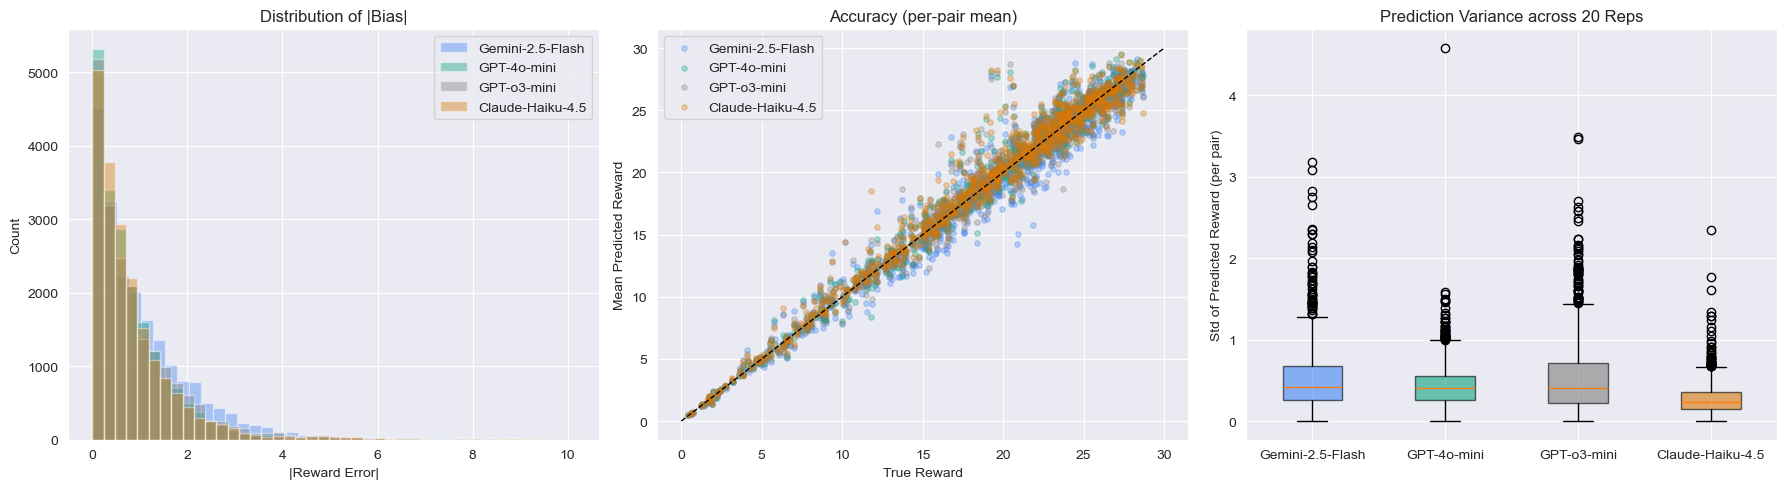

In [17]:
import os
model_files = {
    "Gemini-2.5-Flash": "annotations_irt_time_gemini.csv",
    "GPT-4o-mini":      "annotations_irt_time_gpt4omini.csv",
    "GPT-o3-mini":      "annotations_irt_time_o3mini.csv",
    "Claude-Haiku-4.5": "annotations_irt_time_claude_haiku.csv",
}

cost = {
    "Gemini-2.5-Flash": "$1.14",
    "GPT-4o-mini":      "$0.48",
    "GPT-o3-mini":      "$37.26",
    "Claude-Haiku-4.5": "$8.11",
}

summary_rows = []
all_model_dfs = {}

for model_label, fpath in model_files.items():
    if not os.path.exists(fpath):
        print(f"{fpath} not found, skipping {model_label}")
        continue

    mdf = pd.read_csv(fpath)
    mdf = mdf[mdf['status'] == 'success'].copy()
    mdf['true_reward'] = mdf.apply(
        lambda r: mu_r[int(r.state_id), int(r.action_id)], axis=1)
    mdf['error'] = mdf['true_reward'] - mdf['predicted_reward']
    mdf['abs_error'] = mdf['error'].abs()
    all_model_dfs[model_label] = mdf

    pair_stats = mdf.groupby(['state_id', 'action_id']).agg(
        pred_std=('predicted_reward', 'std'),
        rt_std=('predicted_rt_sec', 'std'),
    )

    summary_rows.append({
        "Model": model_label,
        "Mean |Bias|": mdf['abs_error'].mean(),
        "Median |Bias|": mdf['abs_error'].median(),
        "Std(pred_reward)": pair_stats['pred_std'].mean(),
        "Cost (20 reps)": cost[model_label],
    })

summary = pd.DataFrame(summary_rows)
print(summary.round(3).to_string(index=False))

# --- Visualization ---
if len(all_model_dfs) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {'Gemini-2.5-Flash': '#4285F4', 'GPT-4o-mini': '#10A37F',
              'Claude-Haiku-4.5': '#D97706'}

    # 1: |Bias| distribution comparison
    for label, mdf in all_model_dfs.items():
        axes[0].hist(mdf['abs_error'], bins=40, alpha=0.4,
                     label=label, color=colors.get(label, 'gray'))
    axes[0].set_xlabel('|Reward Error|')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of |Bias|')
    axes[0].legend()

    # 2: Predicted vs True scatter
    for label, mdf in all_model_dfs.items():
        pair_means = mdf.groupby(['state_id', 'action_id']).agg(
            pred_mean=('predicted_reward', 'mean'),
            true_r=('true_reward', 'first'),
        ).reset_index()
        axes[1].scatter(pair_means['true_r'], pair_means['pred_mean'],
                        alpha=0.3, s=15, label=label,
                        color=colors.get(label, 'gray'))
    axes[1].plot([0, 30], [0, 30], 'k--', lw=1)
    axes[1].set_xlabel('True Reward')
    axes[1].set_ylabel('Mean Predicted Reward')
    axes[1].set_title('Accuracy (per-pair mean)')
    axes[1].legend()

    # 3: Variance comparison (boxplot of per-pair std)
    box_data, box_labels = [], []
    for label, mdf in all_model_dfs.items():
        stds = mdf.groupby(['state_id', 'action_id'])['predicted_reward'].std()
        box_data.append(stds.values)
        box_labels.append(label)
    bp = axes[2].boxplot(box_data, labels=box_labels, patch_artist=True)
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(colors.get(label, 'gray'))
        patch.set_alpha(0.6)
    axes[2].set_ylabel('Std of Predicted Reward (per pair)')
    axes[2].set_title('Prediction Variance across 20 Reps')

    plt.tight_layout()

    plt.savefig("LLMs.png", bbox_inches='tight',dpi=300)
    plt.show()